# ResNet — Fase 1: Grid de Experimentos
**Arquiteturas:** ResNet-18, ResNet-34, ResNet-50  
**Loss functions:** CrossEntropyLoss, MultiMarginLoss  
**Optimizadores:** ADAM, RMSprop  
**Total:** 12 runs (3 × 2 × 2)

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

In [2]:
import os
import sys
import json
import time
import random
import warnings
import copy

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

warnings.filterwarnings("ignore")

# ── Reprodutibilidade ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Device:", device)

sys.path.append(os.path.abspath("../src"))
from dataset import ButterflyDataset
from transforms import get_transforms

/Users/ritapduarte/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Device: mps


In [3]:
# ── Dataset ────────────────────────────────────────────────────────────────────
path = kagglehub.competition_download('aca-butterflies')
competition_dir = path
train_dir = os.path.join(competition_dir, "train")
test_dir  = os.path.join(competition_dir, "test")
train_csv = os.path.join(competition_dir, "train.csv")
test_csv  = os.path.join(competition_dir, "test.csv")

df = pd.read_csv(train_csv)

train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

classes       = sorted(df["label"].unique())
class_to_idx  = {cls: i for i, cls in enumerate(classes)}
idx_to_class  = {i: cls for cls, i in class_to_idx.items()}
NUM_CLASSES   = len(classes)

train_df["label_idx"] = train_df["label"].map(class_to_idx).astype(int)
val_df["label_idx"]   = val_df["label"].map(class_to_idx).astype(int)

train_transform, val_transform, test_transform = get_transforms()

train_dataset = ButterflyDataset(train_df, train_dir, transform=train_transform)
val_dataset   = ButterflyDataset(val_df,   train_dir, transform=val_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Classes: {NUM_CLASSES}")

Train: 4159 | Val: 1040 | Classes: 75


In [4]:
# ── Construtor de modelos ──────────────────────────────────────────────────────
def build_model(arch: str, num_classes: int) -> nn.Module:
    """
    Carrega ResNet pré-treinada no ImageNet e substitui
    a camada fully-connected final pelo número de classes do dataset.
    """
    weights_map = {
        "resnet18": models.ResNet18_Weights.IMAGENET1K_V1,
        "resnet34": models.ResNet34_Weights.IMAGENET1K_V1,
        "resnet50": models.ResNet50_Weights.IMAGENET1K_V2,
    }
    model_fn_map = {
        "resnet18": models.resnet18,
        "resnet34": models.resnet34,
        "resnet50": models.resnet50,
    }

    assert arch in weights_map, f"Arquitectura '{arch}' não suportada."

    model = model_fn_map[arch](weights=weights_map[arch])
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

In [5]:
# ── Funções de treino e validação ──────────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = accuracy_score(all_labels, all_preds)
    epoch_f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return epoch_loss, epoch_acc, epoch_f1


def val_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = accuracy_score(all_labels, all_preds)
    epoch_f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return epoch_loss, epoch_acc, epoch_f1

In [6]:
# ── Runner de um único experimento ─────────────────────────────────────────────
def run_experiment(
    arch: str,
    loss_name: str,
    opt_name: str,
    num_classes: int,
    train_loader,
    val_loader,
    device,
    num_epochs: int = 15,
    lr: float = 1e-4,
    patience: int = 5,
):
    """
    Treina um modelo com a combinação dada e devolve o histórico
    e os pesos do melhor epoch (early stopping por val accuracy).
    """
    run_id = f"{arch}__{loss_name}__{opt_name}"
    print(f"\n{'='*60}")
    print(f"  {run_id}")
    print(f"{'='*60}")

    # ── Modelo ────────────────────────────────────────────────────
    model = build_model(arch, num_classes).to(device)

    # ── Loss ──────────────────────────────────────────────────────
    if loss_name == "CrossEntropyLoss":
        criterion = nn.CrossEntropyLoss()
    elif loss_name == "MultiMarginLoss":
        criterion = nn.MultiMarginLoss()
    else:
        raise ValueError(f"Loss '{loss_name}' não suportada.")

    # ── Optimizador ───────────────────────────────────────────────
    if opt_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    elif opt_name == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=1e-4, momentum=0.9)
    else:
        raise ValueError(f"Optimizador '{opt_name}' não suportado.")

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc":  [], "val_acc":  [],
        "train_f1":   [], "val_f1":   [],
    }

    best_val_acc   = 0.0
    best_weights   = None
    patience_count = 0
    t_start        = time.time()

    for epoch in range(1, num_epochs + 1):
        t_loss, t_acc, t_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc, v_f1 = val_epoch(model, val_loader, criterion, device)

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)
        history["train_f1"].append(t_f1)
        history["val_f1"].append(v_f1)

        print(
            f"  Epoch {epoch:02d}/{num_epochs} "
            f"| Train loss {t_loss:.4f}  acc {t_acc:.4f}  F1 {t_f1:.4f}"
            f"| Val loss {v_loss:.4f}  acc {v_acc:.4f}  F1 {v_f1:.4f}"
        )

        # Early stopping & best model checkpoint
        if v_acc > best_val_acc:
            best_val_acc  = v_acc
            best_weights  = copy.deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"  Early stopping na epoch {epoch}.")
                break

    elapsed = time.time() - t_start
    print(f"  Melhor val acc: {best_val_acc:.4f} | Tempo total: {elapsed:.1f}s")

    # Devolve modelo com os melhores pesos
    model.load_state_dict(best_weights)

    return {
        "run_id":       run_id,
        "arch":         arch,
        "loss":         loss_name,
        "optimizer":    opt_name,
        "best_val_acc": best_val_acc,
        "best_val_f1":  max(history["val_f1"]),
        "epochs_ran":   len(history["val_acc"]),
        "train_time_s": round(elapsed, 1),
        "history":      history,
        "model":        model,
    }

In [7]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

In [8]:
# ── Grid de experimentos ───────────────────────────────────────────────────────
ARCHITECTURES = ["resnet18", "resnet34", "resnet50"]
LOSS_FUNCTIONS = ["CrossEntropyLoss", "MultiMarginLoss"]
OPTIMIZERS     = ["Adam", "RMSprop"]

NUM_EPOCHS = 15
LR         = 1e-4
PATIENCE   = 5

all_results = []

for arch in ARCHITECTURES:
    for loss_name in LOSS_FUNCTIONS:
        for opt_name in OPTIMIZERS:
            result = run_experiment(
                arch        = arch,
                loss_name   = loss_name,
                opt_name    = opt_name,
                num_classes = NUM_CLASSES,
                train_loader= train_loader,
                val_loader  = val_loader,
                device      = device,
                num_epochs  = NUM_EPOCHS,
                lr          = LR,
                patience    = PATIENCE,
            )
            all_results.append(result)

print("\n✓ Grid completo.")


  resnet18__CrossEntropyLoss__Adam
  Epoch 01/15 | Train loss 2.4270  acc 0.5509  F1 0.5618| Val loss 0.8643  acc 0.8442  F1 0.8338
  Epoch 02/15 | Train loss 0.7125  acc 0.8880  F1 0.8869| Val loss 0.4521  acc 0.9144  F1 0.9121
  Epoch 03/15 | Train loss 0.3604  acc 0.9409  F1 0.9404| Val loss 0.3350  acc 0.9250  F1 0.9245
  Epoch 04/15 | Train loss 0.2284  acc 0.9594  F1 0.9591| Val loss 0.2978  acc 0.9298  F1 0.9308
  Epoch 05/15 | Train loss 0.1492  acc 0.9752  F1 0.9751| Val loss 0.2503  acc 0.9385  F1 0.9390
  Epoch 06/15 | Train loss 0.1014  acc 0.9856  F1 0.9856| Val loss 0.2639  acc 0.9317  F1 0.9325
  Epoch 07/15 | Train loss 0.0798  acc 0.9873  F1 0.9873| Val loss 0.2574  acc 0.9413  F1 0.9416
  Epoch 08/15 | Train loss 0.0617  acc 0.9899  F1 0.9899| Val loss 0.2329  acc 0.9452  F1 0.9457
  Epoch 09/15 | Train loss 0.0463  acc 0.9930  F1 0.9931| Val loss 0.2558  acc 0.9365  F1 0.9367
  Epoch 10/15 | Train loss 0.0385  acc 0.9950  F1 0.9950| Val loss 0.2227  acc 0.9510  F1 0

100%|██████████| 83.3M/83.3M [00:04<00:00, 19.0MB/s]


  Epoch 01/15 | Train loss 2.0100  acc 0.6071  F1 0.6201| Val loss 0.6102  acc 0.8808  F1 0.8723
  Epoch 02/15 | Train loss 0.4882  acc 0.9026  F1 0.9017| Val loss 0.3494  acc 0.9135  F1 0.9111
  Epoch 03/15 | Train loss 0.2397  acc 0.9529  F1 0.9526| Val loss 0.3177  acc 0.9125  F1 0.9123
  Epoch 04/15 | Train loss 0.1727  acc 0.9615  F1 0.9616| Val loss 0.2848  acc 0.9231  F1 0.9241
  Epoch 05/15 | Train loss 0.1091  acc 0.9767  F1 0.9765| Val loss 0.2786  acc 0.9337  F1 0.9339
  Epoch 06/15 | Train loss 0.0939  acc 0.9803  F1 0.9802| Val loss 0.3114  acc 0.9192  F1 0.9176
  Epoch 07/15 | Train loss 0.0607  acc 0.9897  F1 0.9897| Val loss 0.2661  acc 0.9375  F1 0.9390
  Epoch 08/15 | Train loss 0.0475  acc 0.9911  F1 0.9910| Val loss 0.3587  acc 0.9125  F1 0.9093
  Epoch 09/15 | Train loss 0.0609  acc 0.9841  F1 0.9841| Val loss 0.2978  acc 0.9269  F1 0.9286
  Epoch 10/15 | Train loss 0.0540  acc 0.9885  F1 0.9885| Val loss 0.3409  acc 0.9154  F1 0.9177
  Epoch 11/15 | Train loss 0.0

100%|██████████| 97.8M/97.8M [00:06<00:00, 15.8MB/s]


  Epoch 01/15 | Train loss 2.7383  acc 0.4816  F1 0.4906| Val loss 0.6551  acc 0.8538  F1 0.8461
  Epoch 02/15 | Train loss 0.5217  acc 0.8851  F1 0.8835| Val loss 0.3018  acc 0.9192  F1 0.9197
  Epoch 03/15 | Train loss 0.2366  acc 0.9440  F1 0.9438| Val loss 0.2527  acc 0.9279  F1 0.9286
  Epoch 04/15 | Train loss 0.1406  acc 0.9666  F1 0.9668| Val loss 0.2541  acc 0.9202  F1 0.9191
  Epoch 05/15 | Train loss 0.1190  acc 0.9690  F1 0.9688| Val loss 0.2259  acc 0.9346  F1 0.9353
  Epoch 06/15 | Train loss 0.0710  acc 0.9812  F1 0.9814| Val loss 0.2451  acc 0.9231  F1 0.9226
  Epoch 07/15 | Train loss 0.0675  acc 0.9815  F1 0.9814| Val loss 0.2490  acc 0.9308  F1 0.9333
  Epoch 08/15 | Train loss 0.0407  acc 0.9885  F1 0.9884| Val loss 0.2374  acc 0.9375  F1 0.9381
  Epoch 09/15 | Train loss 0.0444  acc 0.9906  F1 0.9906| Val loss 0.2216  acc 0.9404  F1 0.9409
  Epoch 10/15 | Train loss 0.0318  acc 0.9928  F1 0.9929| Val loss 0.2367  acc 0.9462  F1 0.9471
  Epoch 11/15 | Train loss 0.0

In [9]:
# ── Tabela comparativa ─────────────────────────────────────────────────────────
rows = []
for r in all_results:
    rows.append({
        "Arquitectura":  r["arch"],
        "Loss":          r["loss"],
        "Optimizador":   r["optimizer"],
        "Val Accuracy":  round(r["best_val_acc"], 4),
        "Val Macro F1":  round(r["best_val_f1"],  4),
        "Epochs ran":    r["epochs_ran"],
        "Tempo (s)":     r["train_time_s"],
    })

results_df = pd.DataFrame(rows).sort_values("Val Accuracy", ascending=False)
results_df = results_df.reset_index(drop=True)

print(results_df.to_string(index=False))

Arquitectura             Loss Optimizador  Val Accuracy  Val Macro F1  Epochs ran  Tempo (s)
    resnet18 CrossEntropyLoss        Adam        0.9548        0.9560          15      460.4
    resnet50 CrossEntropyLoss        Adam        0.9462        0.9471          15     1271.5
    resnet50  MultiMarginLoss        Adam        0.9423        0.9427          15     1260.1
    resnet34 CrossEntropyLoss        Adam        0.9375        0.9390          12      721.0
    resnet34  MultiMarginLoss        Adam        0.9356        0.9352          15      716.9
    resnet18  MultiMarginLoss        Adam        0.9154        0.9162          14      437.5
    resnet50 CrossEntropyLoss     RMSprop        0.8740        0.8712          15     1269.0
    resnet18 CrossEntropyLoss     RMSprop        0.7865        0.7797          10      312.0
    resnet34 CrossEntropyLoss     RMSprop        0.7596        0.7572          15     7629.0
    resnet50  MultiMarginLoss     RMSprop        0.7106        0.6957 

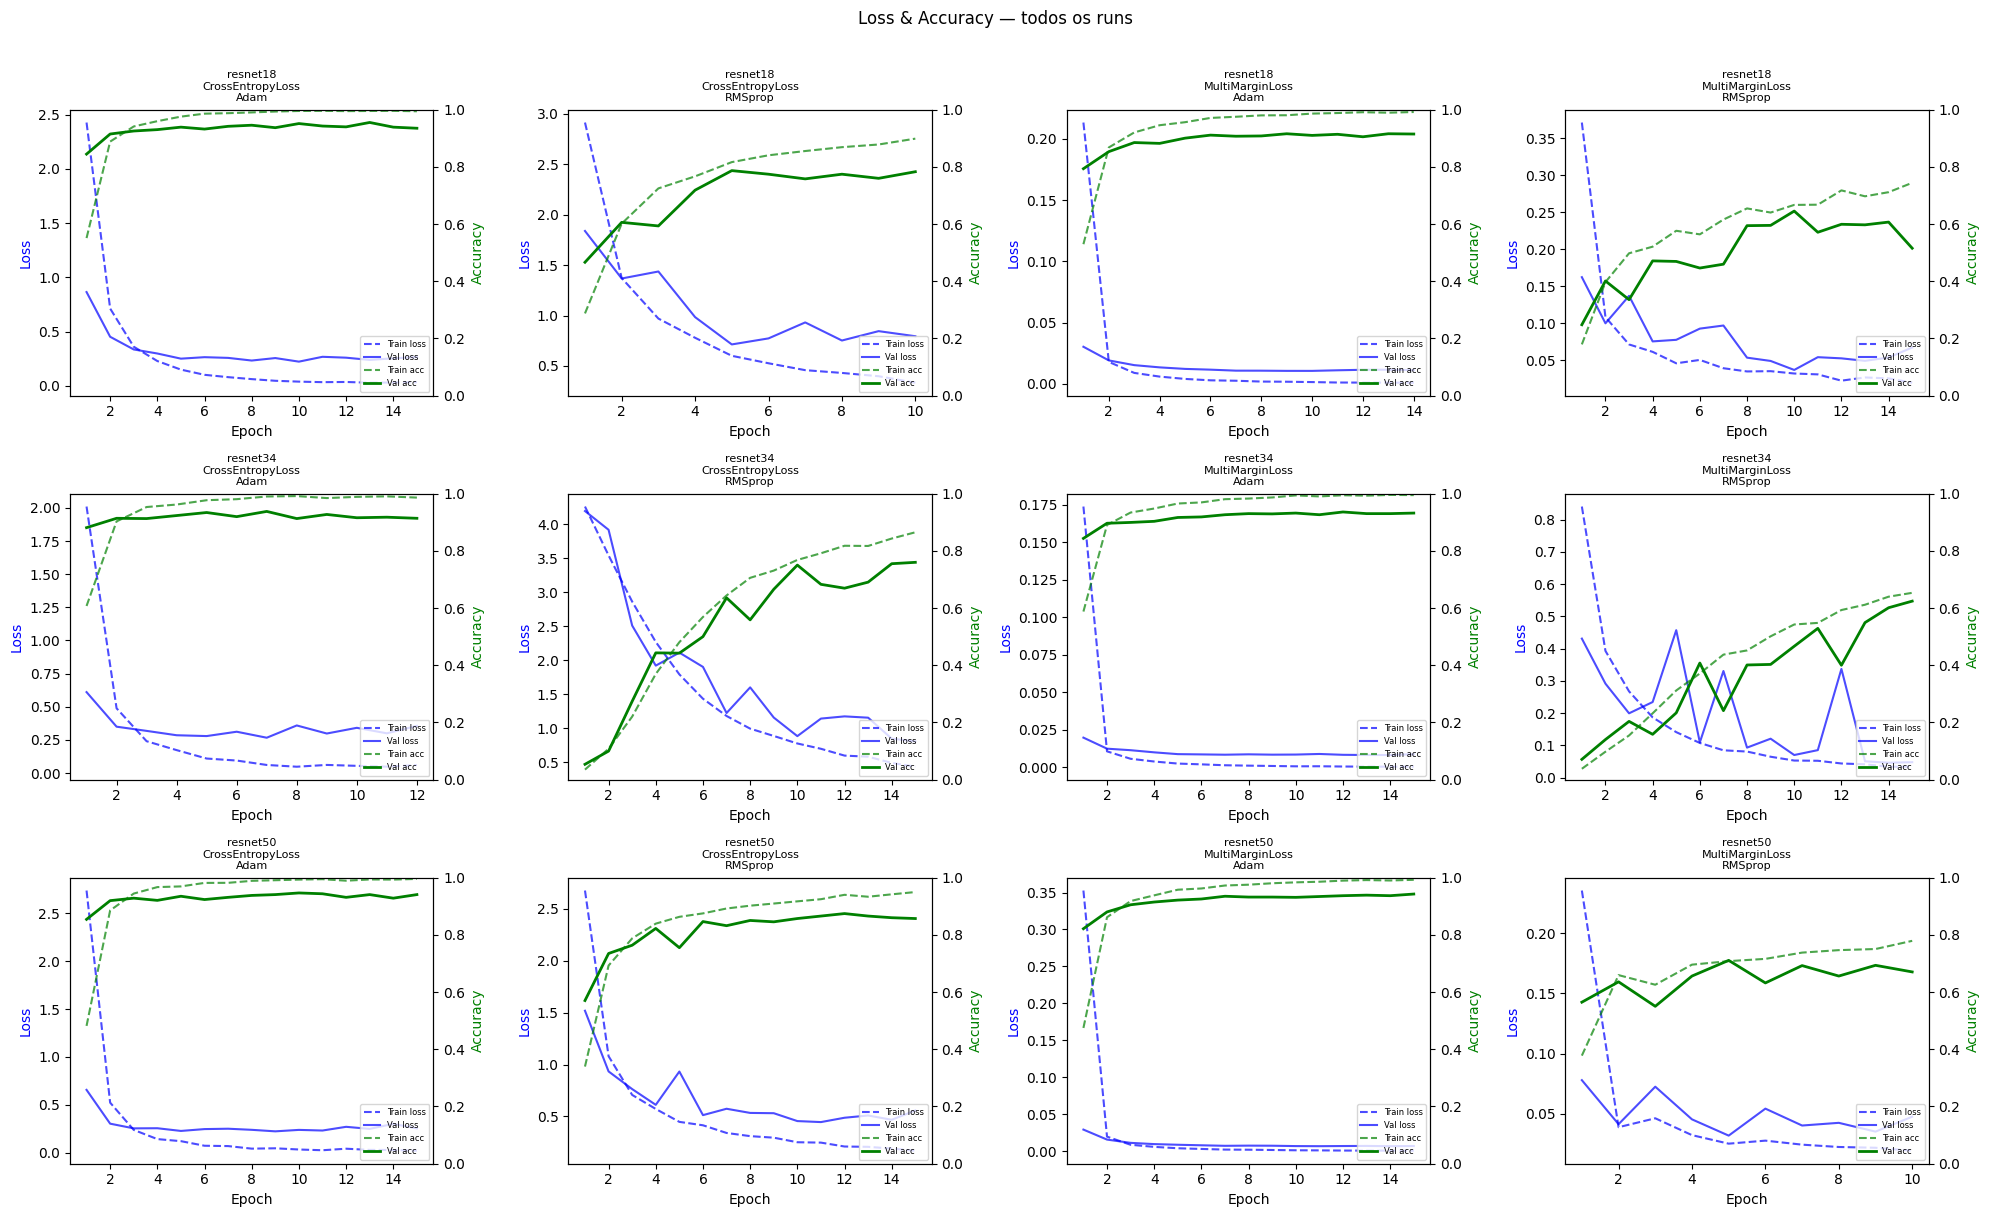

In [10]:
# ── Curvas de loss e accuracy por run ──────────────────────────────────────────
n_runs = len(all_results)
ncols  = 4
nrows  = (n_runs + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for i, r in enumerate(all_results):
    ax  = axes[i]
    h   = r["history"]
    eps = range(1, len(h["train_loss"]) + 1)

    ax2 = ax.twinx()
    ax.plot(eps,  h["train_loss"], "b--",  alpha=0.7, label="Train loss")
    ax.plot(eps,  h["val_loss"],   "b-",   alpha=0.7, label="Val loss")
    ax2.plot(eps, h["train_acc"],  "g--",  alpha=0.7, label="Train acc")
    ax2.plot(eps, h["val_acc"],    "g-",   linewidth=2, label="Val acc")

    ax.set_title(r["run_id"].replace("__", "\n"), fontsize=8)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss",     color="b")
    ax2.set_ylabel("Accuracy",color="g")
    ax2.set_ylim(0, 1)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=6, loc="lower right")

# Esconder subplots a mais
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Loss & Accuracy — todos os runs", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("resnet_curves.png", dpi=150, bbox_inches="tight")
plt.show()

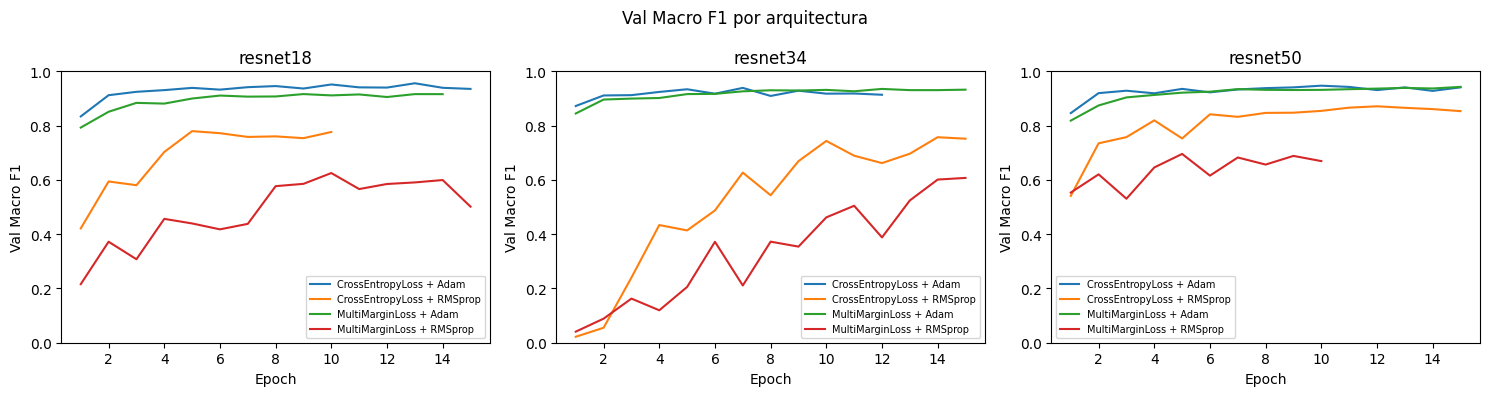

In [11]:
# ── Macro F1 — curvas do melhor run de cada arquitectura ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, arch in zip(axes, ARCHITECTURES):
    arch_runs = [r for r in all_results if r["arch"] == arch]
    for r in arch_runs:
        h   = r["history"]
        eps = range(1, len(h["val_f1"]) + 1)
        label = f"{r['loss']} + {r['optimizer']}"
        ax.plot(eps, h["val_f1"], label=label)
    ax.set_title(arch)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val Macro F1")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)

plt.suptitle("Val Macro F1 por arquitectura", fontsize=12)
plt.tight_layout()
plt.savefig("resnet_f1_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# ── Selecção do melhor modelo ──────────────────────────────────────────────────
best_result = max(all_results, key=lambda r: r["best_val_acc"])

print("Melhor run:", best_result["run_id"])
print(f"  Val Accuracy : {best_result['best_val_acc']:.4f}")
print(f"  Val Macro F1 : {best_result['best_val_f1']:.4f}")
print(f"  Epochs       : {best_result['epochs_ran']}")
print(f"  Tempo        : {best_result['train_time_s']}s")

best_model = best_result["model"]

# Guarda os pesos do melhor modelo
torch.save(best_model.state_dict(), "best_resnet.pth")
print("\nPesos guardados em best_resnet.pth")

Melhor run: resnet18__CrossEntropyLoss__Adam
  Val Accuracy : 0.9548
  Val Macro F1 : 0.9560
  Epochs       : 15
  Tempo        : 460.4s

Pesos guardados em best_resnet.pth


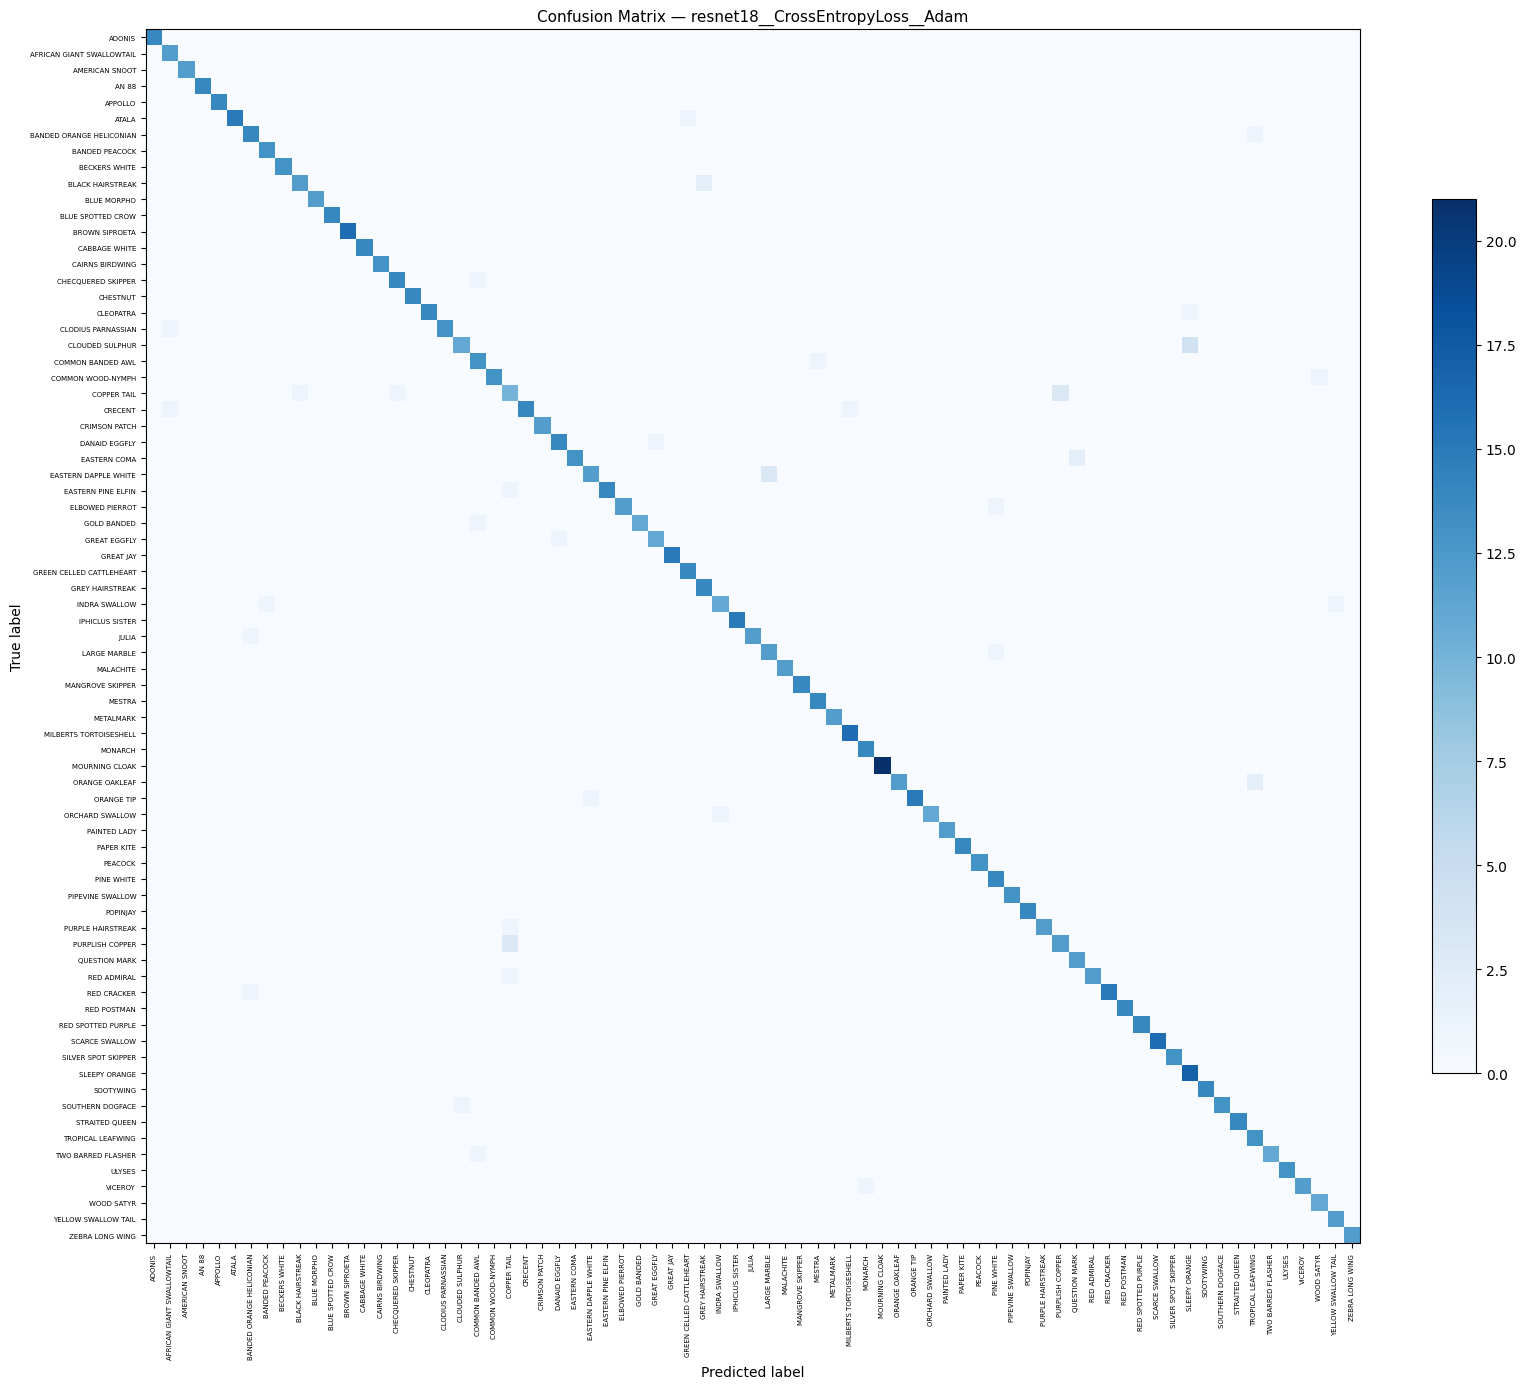

In [13]:
# ── Confusion matrix do melhor modelo (val set) ───────────────────────────────
best_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        preds  = best_model(images).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_title(f"Confusion Matrix — {best_result['run_id']}", fontsize=11)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(classes, rotation=90, fontsize=5)
ax.set_yticklabels(classes, fontsize=5)
plt.tight_layout()
plt.savefig("resnet_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# ── Geração do ficheiro de submission para Kaggle ─────────────────────────────
# Usa o submission.csv de exemplo para garantir os filenames correctos
sample_submission = pd.read_csv("/Users/ritapduarte/4ano/2semestre/ACA/submission.csv") 
test_df = pd.DataFrame({"filename": sample_submission["filename"]})

test_dataset = ButterflyDataset(test_df, test_dir, transform=test_transform, is_test=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

best_model.eval()
filenames_list, predictions = [], []

with torch.no_grad():
    for images, fnames in test_loader:
        images = images.to(device)
        preds  = best_model(images).argmax(dim=1).cpu().numpy()
        filenames_list.extend(fnames)
        predictions.extend([idx_to_class[p] for p in preds])

submission = pd.DataFrame({
    "filename": filenames_list,
    "label":    predictions,
})
submission.to_csv("submission_resnet.csv", index=False)
print(f"Linhas geradas: {len(submission)}")  # deve ser 1300
submission.head()

Linhas geradas: 1300


,filename,label
0,Image_0.jpg,RED ADMIRAL
1,Image_1.jpg,APPOLLO
2,Image_2.jpg,ZEBRA LONG WING
3,Image_3.jpg,COMMON BANDED AWL
4,Image_4.jpg,PAPER KITE


In [18]:
# ── Exportar tabela de resultados para CSV  ─────────────
results_df.to_csv("resnet_results_table.csv", index=False)
print("Tabela exportada para resnet_results_table.csv")
results_df

Tabela exportada para resnet_results_table.csv


,Arquitectura,Loss,Optimizador,Val Accuracy,Val Macro F1,Epochs ran,Tempo (s)
0,resnet18,CrossEntropyLoss,Adam,0.9548,0.9560,15,460.4
1,resnet50,CrossEntropyLoss,Adam,0.9462,0.9471,15,1271.5
2,resnet50,MultiMarginLoss,Adam,0.9423,0.9427,15,1260.1
3,resnet34,CrossEntropyLoss,Adam,0.9375,0.9390,12,721.0
4,resnet34,MultiMarginLoss,Adam,0.9356,0.9352,15,716.9
5,resnet18,MultiMarginLoss,Adam,0.9154,0.9162,14,437.5
6,resnet50,CrossEntropyLoss,RMSprop,0.8740,0.8712,15,1269.0
7,resnet18,CrossEntropyLoss,RMSprop,0.7865,0.7797,10,312.0
8,resnet34,CrossEntropyLoss,RMSprop,0.7596,0.7572,15,7629.0
9,resnet50,MultiMarginLoss,RMSprop,0.7106,0.6957,10,846.8


In [25]:
# ── Ensemble: 3 melhores modelos globais ──────────────────────────────────────
top3 = sorted(all_results, key=lambda r: r["best_val_acc"], reverse=True)[:3]

for r in top3:
    print(f"{r['arch']} | {r['loss']} | {r['optimizer']} — Val Acc: {r['best_val_acc']:.4f}")

ensemble_models = [r["model"] for r in top3]

# Avaliar ensemble no val set
for m in ensemble_models:
    m.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        probs  = sum(
            torch.softmax(m(images), dim=1) for m in ensemble_models
        ) / len(ensemble_models)
        preds  = probs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

ens_acc = accuracy_score(all_labels, all_preds)
ens_f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
print(f"\nEnsemble top-3 — Val Acc: {ens_acc:.4f} | Val Macro F1: {ens_f1:.4f}")

resnet18 | CrossEntropyLoss | Adam — Val Acc: 0.9548
resnet50 | CrossEntropyLoss | Adam — Val Acc: 0.9462
resnet50 | MultiMarginLoss | Adam — Val Acc: 0.9423

Ensemble top-3 — Val Acc: 0.9596 | Val Macro F1: 0.9604


In [26]:
# ── Submission do ensemble top-3 ──────────────────────────────────────────────
sample_submission = pd.read_csv("/Users/ritapduarte/4ano/2semestre/ACA/submission.csv")
test_df_ens = pd.DataFrame({"filename": sample_submission["filename"]})

test_dataset_ens = ButterflyDataset(test_df_ens, test_dir, transform=test_transform, is_test=True)
test_loader_ens  = DataLoader(test_dataset_ens, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

for m in ensemble_models:
    m.eval()

filenames_list, predictions = [], []

with torch.no_grad():
    for images, fnames in test_loader_ens:
        images = images.to(device)
        probs  = sum(
            torch.softmax(m(images), dim=1) for m in ensemble_models
        ) / len(ensemble_models)
        preds  = probs.argmax(dim=1).cpu().numpy()
        filenames_list.extend(fnames)
        predictions.extend([idx_to_class[p] for p in preds])

submission_ens = pd.DataFrame({
    "filename": filenames_list,
    "label":    predictions,
})
submission_ens.to_csv("../outputs/submissions/submission_ensemble_top3.csv", index=False)
print(f"Submission ensemble guardada ({len(submission_ens)} linhas)")
submission_ens.head()

Submission ensemble guardada (1300 linhas)


,filename,label
0,Image_0.jpg,RED ADMIRAL
1,Image_1.jpg,APPOLLO
2,Image_2.jpg,ZEBRA LONG WING
3,Image_3.jpg,COMMON BANDED AWL
4,Image_4.jpg,PAPER KITE
